In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [70]:
os.getcwd()

'c:\\Users\\AnuragS\\OneDrive\\ml_projects\\telecom_churn'

In [71]:
df = pd.read_csv('customer_churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [72]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [73]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

1. TotalCharges can not be string.
2. Churn should be 1,0

### Total Charges

while trying to convert TotalCharges to float, it is not allowing to do so, saying that there are values which have ' '. Those should be null as they are very new customers. By analyzing it is figured out that TotalCharges = MonthlyCharges * Tenure.

So, whereever we are getting this issue we can replace the values as MonthlyCharges * Tenure.

In [74]:
# df.TotalCharges = df.TotalCharges.replace(' ',np.nan)
# df.TotalCharges = df.TotalCharges.astype(float)

df.TotalCharges = pd.to_numeric(df.TotalCharges,errors='coerce')

In [75]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [76]:
df.isnull().sum()/df.shape[0]

customerID          0.000000
gender              0.000000
SeniorCitizen       0.000000
Partner             0.000000
Dependents          0.000000
tenure              0.000000
PhoneService        0.000000
MultipleLines       0.000000
InternetService     0.000000
OnlineSecurity      0.000000
OnlineBackup        0.000000
DeviceProtection    0.000000
TechSupport         0.000000
StreamingTV         0.000000
StreamingMovies     0.000000
Contract            0.000000
PaperlessBilling    0.000000
PaymentMethod       0.000000
MonthlyCharges      0.000000
TotalCharges        0.001562
Churn               0.000000
dtype: float64

In [77]:
df[df.TotalCharges.isna()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


Where TotalCharges is null, we can drop them as they seems to be the new customers.

In [78]:
df = df[~df.TotalCharges.isna()]
df.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   str    
 1   gender            7032 non-null   str    
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   str    
 4   Dependents        7032 non-null   str    
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   str    
 7   MultipleLines     7032 non-null   str    
 8   InternetService   7032 non-null   str    
 9   OnlineSecurity    7032 non-null   str    
 10  OnlineBackup      7032 non-null   str    
 11  DeviceProtection  7032 non-null   str    
 12  TechSupport       7032 non-null   str    
 13  StreamingTV       7032 non-null   str    
 14  StreamingMovies   7032 non-null   str    
 15  Contract          7032 non-null   str    
 16  PaperlessBilling  7032 non-null   str    
 17  PaymentMeth

In [79]:
categorical_cols = list(df.select_dtypes(include='str').columns)
categorical_cols.remove('customerID')
categorical_cols.append('SeniorCitizen')
categorical_cols

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn',
 'SeniorCitizen']

In [80]:
print('Count of Values for each categorical Columns')
print('-'*35)
for col in categorical_cols:
    print('-'*35)
    print(df[col].value_counts())
    print('-'*35)

Count of Values for each categorical Columns
-----------------------------------
-----------------------------------
gender
Male      3549
Female    3483
Name: count, dtype: int64
-----------------------------------
-----------------------------------
Partner
No     3639
Yes    3393
Name: count, dtype: int64
-----------------------------------
-----------------------------------
Dependents
No     4933
Yes    2099
Name: count, dtype: int64
-----------------------------------
-----------------------------------
PhoneService
Yes    6352
No      680
Name: count, dtype: int64
-----------------------------------
-----------------------------------
MultipleLines
No                  3385
Yes                 2967
No phone service     680
Name: count, dtype: int64
-----------------------------------
-----------------------------------
InternetService
Fiber optic    3096
DSL            2416
No             1520
Name: count, dtype: int64
-----------------------------------
-------------------------

In [81]:
df.Churn.value_counts(normalize=True)*100

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

In [82]:
categorical_cols_wo_churn = [col for col in categorical_cols if col != 'Churn']
categorical_cols_wo_churn

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'SeniorCitizen']

## Univariate Analysis

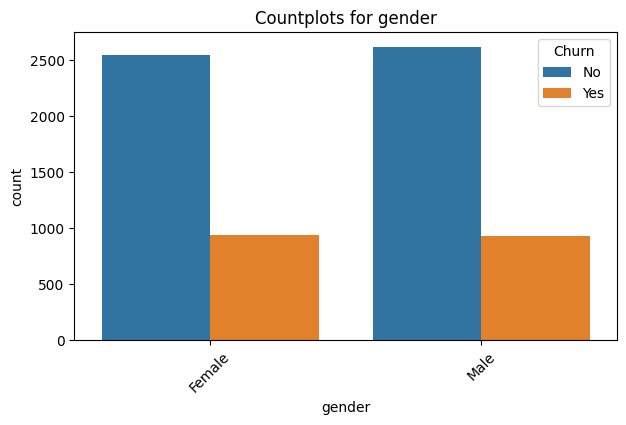

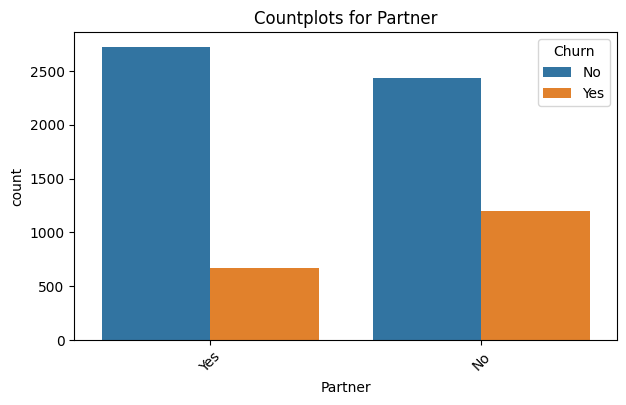

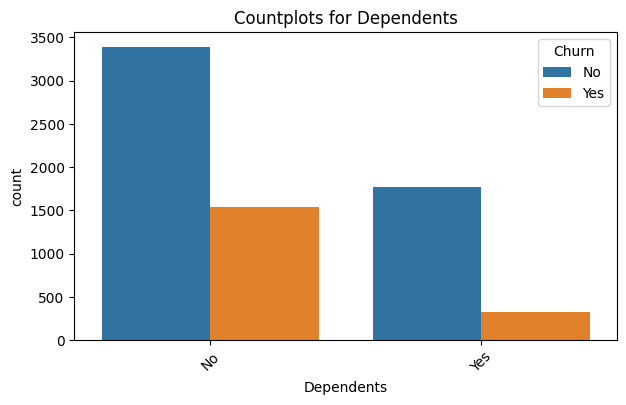

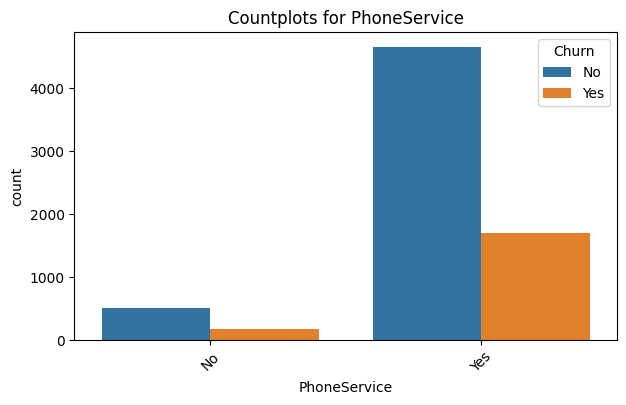

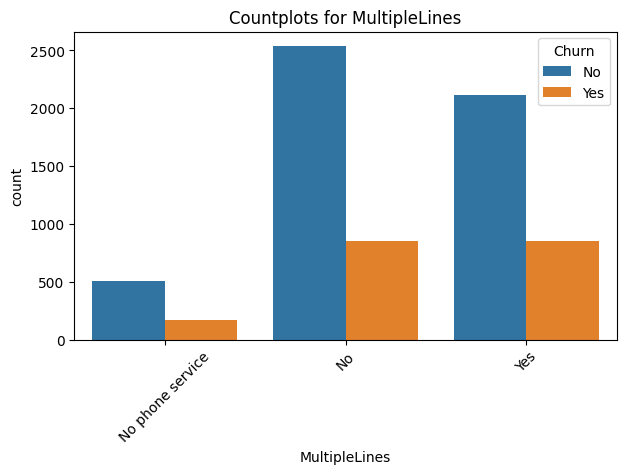

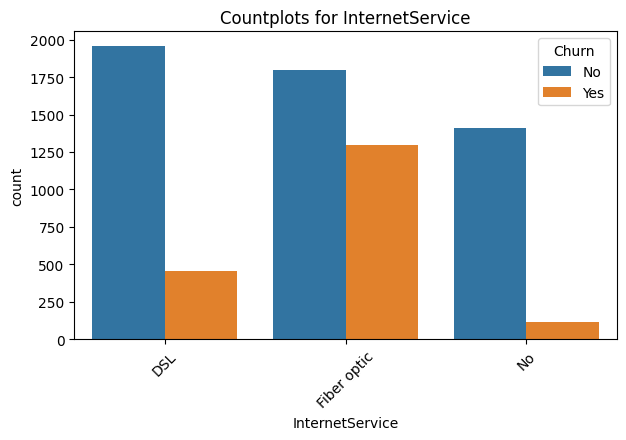

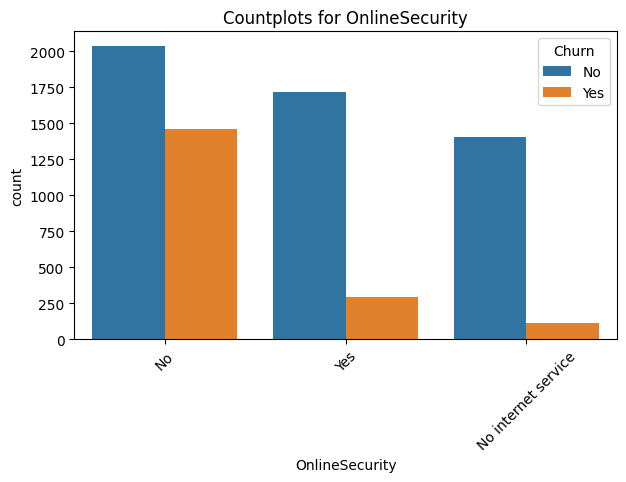

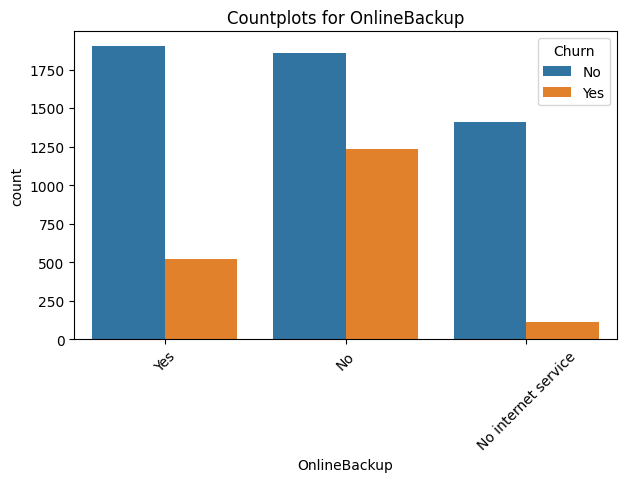

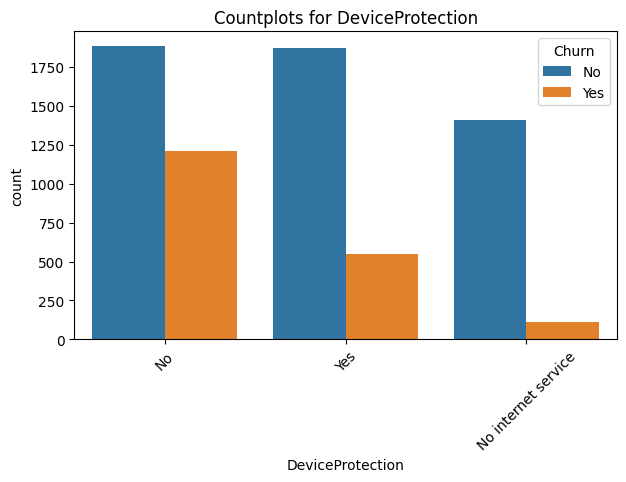

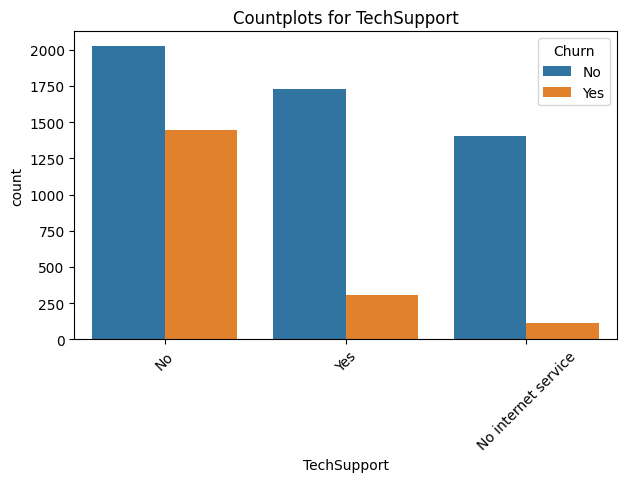

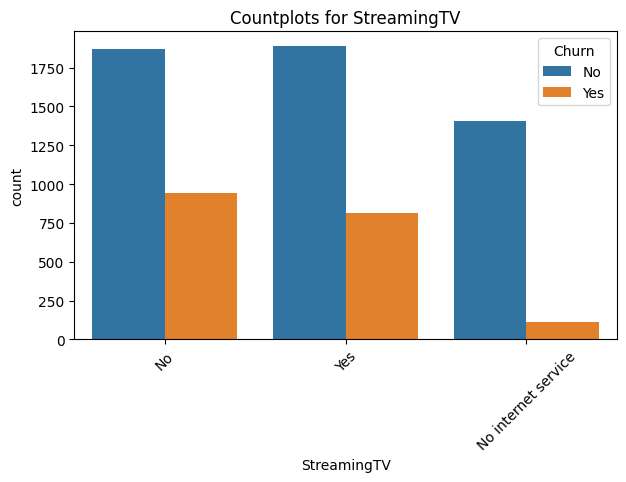

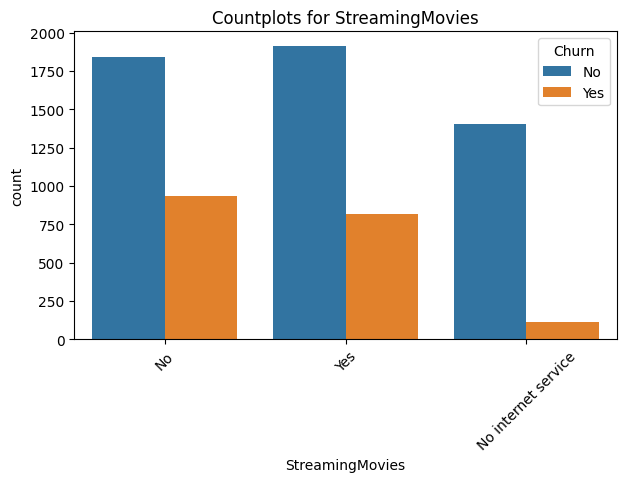

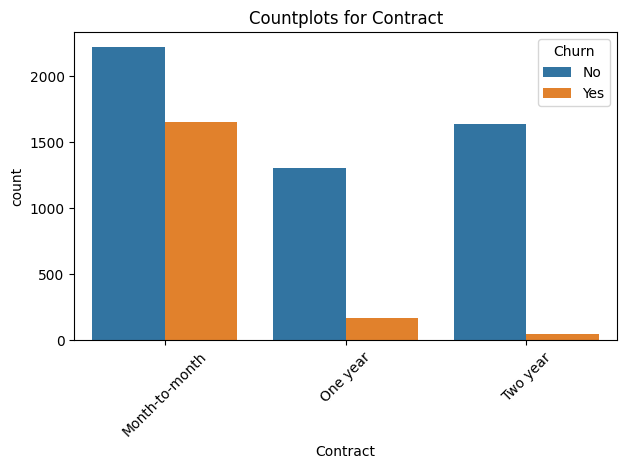

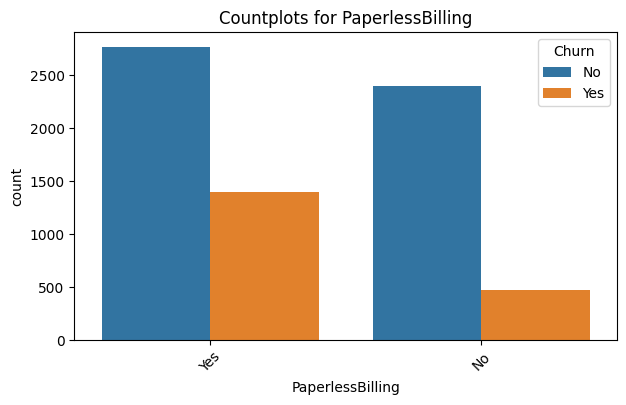

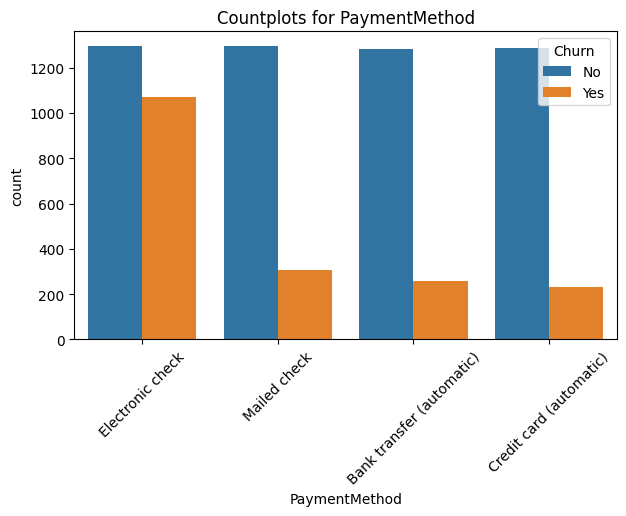

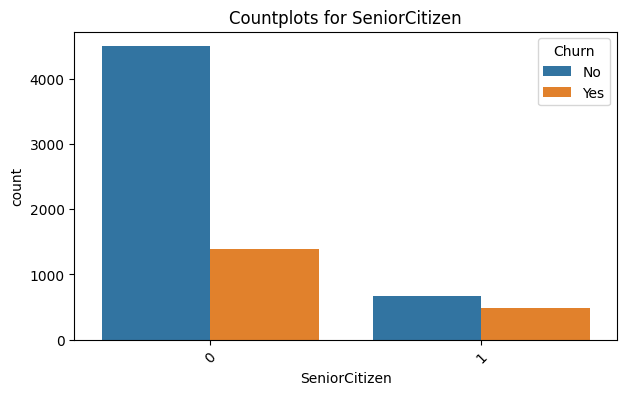

In [83]:
for col in categorical_cols_wo_churn:
    plt.figure(figsize=(7,4))
    sns.countplot(x=df[col],hue=df['Churn'])
    plt.title(f'Countplots for {col}')
    plt.xticks(rotation=45)
    plt.show()

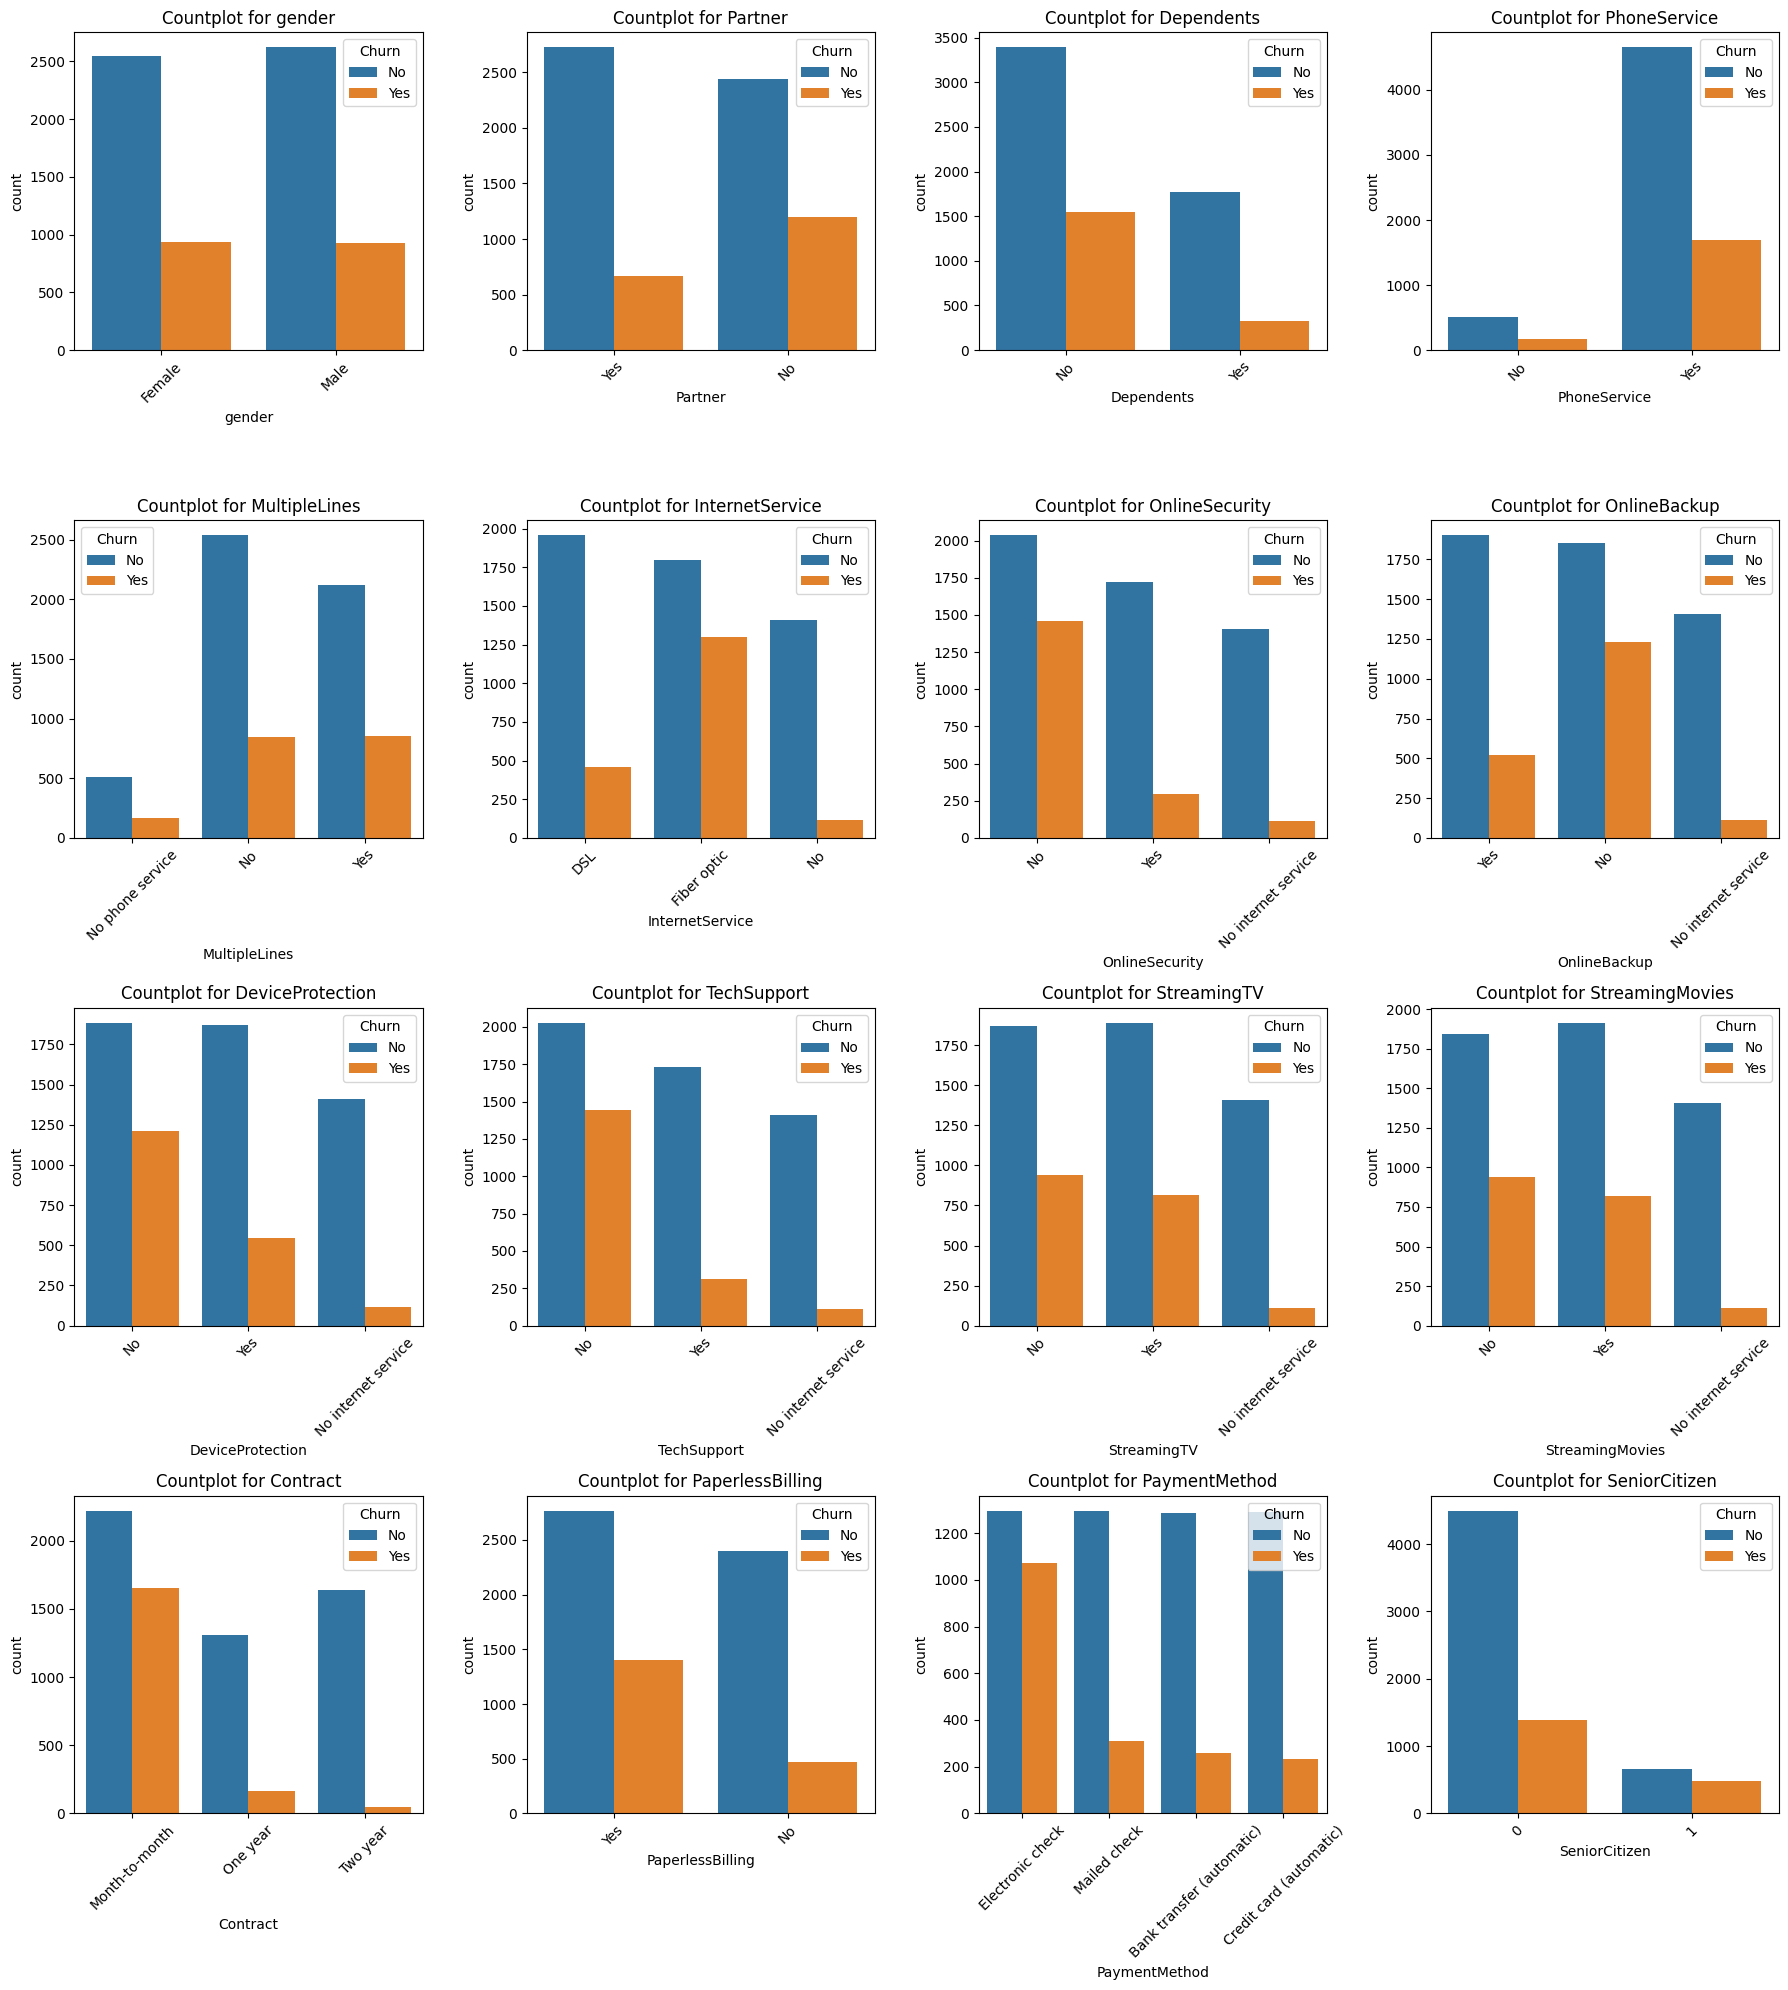

In [84]:
nc = 4
nr = (len(categorical_cols_wo_churn)+nc-1)//nc

fig,axes = plt.subplots(nr,nc,figsize=(18,5*nr))

axes = axes.flatten()

for i, col in enumerate(categorical_cols_wo_churn):
    sns.countplot(x=df[col],hue=df['Churn'],ax=axes[i])
    axes[i].set_title(f'Countplot for {col}')
    axes[i].tick_params(axis='x',rotation=45)

for j in range(len(categorical_cols_wo_churn),len(axes)):
    fig.delaxes(axes[j])

#print(len(axes))

plt.tight_layout()
plt.show()

In [85]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [86]:
num_cols = list(df.select_dtypes(exclude=['str']).columns)
num_cols.remove('SeniorCitizen')
num_cols

['tenure', 'MonthlyCharges', 'TotalCharges']

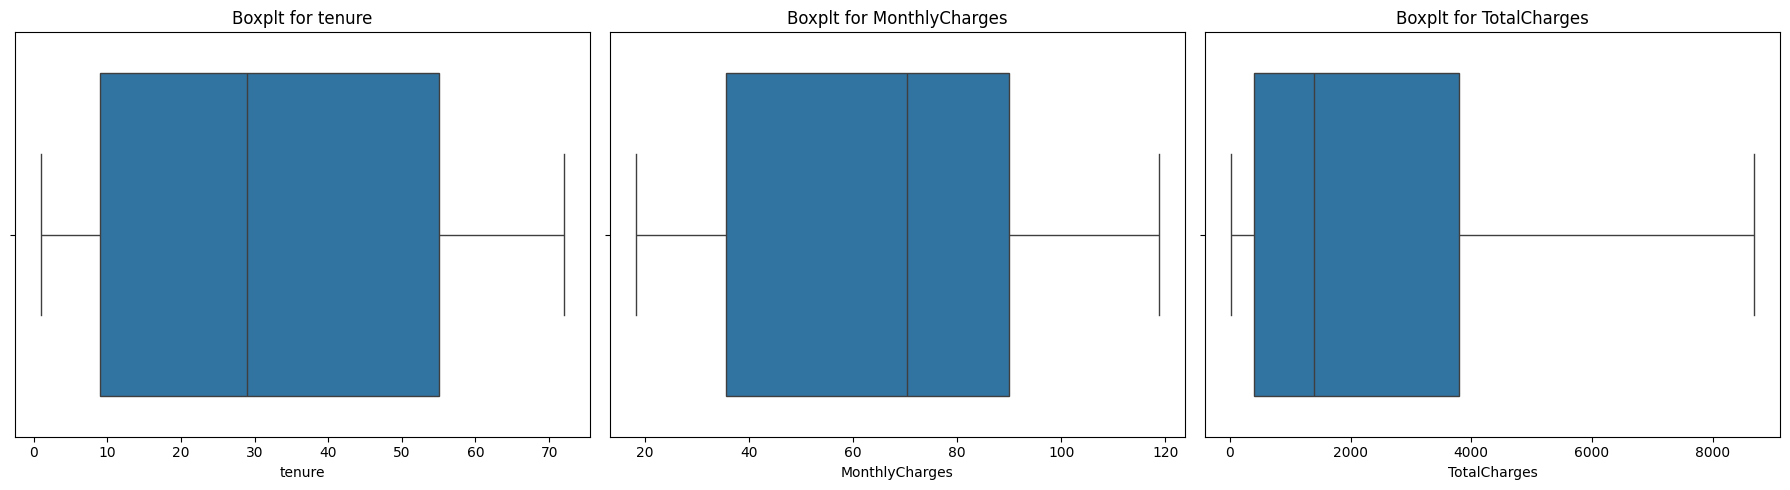

In [87]:
nc = 3
nr = (len(num_cols)+nc-1)//nc

fig,axes = plt.subplots(nr,nc,figsize=(18,5*nr))

axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col],ax=axes[i])
    axes[i].set_title(f'Boxplt for {col}')
    #axes[i].tick_params(axis='x',rotation=45)

for j in range(len(categorical_cols_wo_churn),len(axes)):
    fig.delaxes(axes[j])

#print(len(axes))

plt.tight_layout()
plt.show()

In [88]:
print('-'*35)
for col in categorical_cols_wo_churn:
    print('-'*35)
    print(f'Crosstab Analysis for {col}')
    print(pd.crosstab(df[col],df.Churn))
    print('-'*35)

-----------------------------------
-----------------------------------
Crosstab Analysis for gender
Churn     No  Yes
gender           
Female  2544  939
Male    2619  930
-----------------------------------
-----------------------------------
Crosstab Analysis for Partner
Churn      No   Yes
Partner            
No       2439  1200
Yes      2724   669
-----------------------------------
-----------------------------------
Crosstab Analysis for Dependents
Churn         No   Yes
Dependents            
No          3390  1543
Yes         1773   326
-----------------------------------
-----------------------------------
Crosstab Analysis for PhoneService
Churn           No   Yes
PhoneService            
No             510   170
Yes           4653  1699
-----------------------------------
-----------------------------------
Crosstab Analysis for MultipleLines
Churn               No  Yes
MultipleLines              
No                2536  849
No phone service   510  170
Yes               211

In [89]:
boolean_map_churn = {'Yes':1,'No':0}
df.Churn = df.Churn.map(boolean_map_churn)

num_cols.append('Churn')
df[num_cols].corr()

,tenure,MonthlyCharges,TotalCharges,Churn
tenure,1.000000,0.246862,0.825880,-0.354049
MonthlyCharges,0.246862,1.000000,0.651065,0.192858
TotalCharges,0.825880,0.651065,1.000000,-0.199484
Churn,-0.354049,0.192858,-0.199484,1.000000


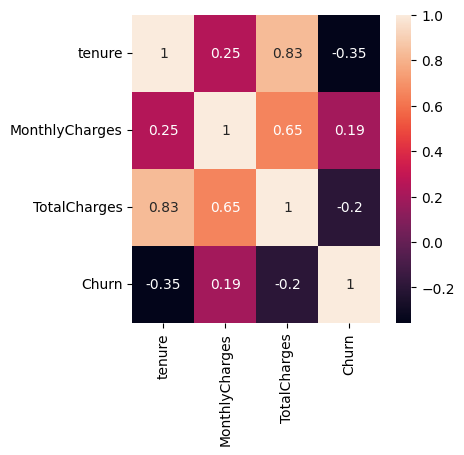

In [90]:
plt.figure(figsize=(4,4))
sns.heatmap(df[num_cols].corr(),annot=True)
plt.show()

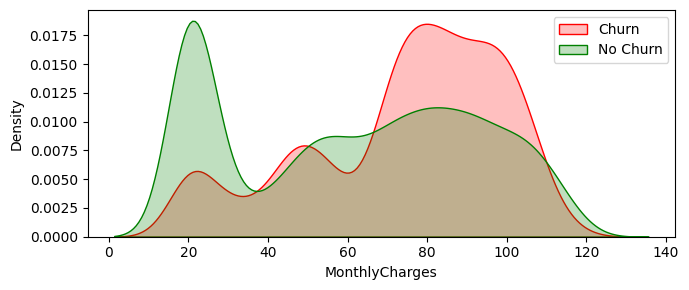

In [91]:
plt.figure(figsize=(7,3))
mc = sns.kdeplot(df.MonthlyCharges[df.Churn==1],fill=True,color='red')
mc = sns.kdeplot(df.MonthlyCharges[df.Churn==0],fill=True,color='green',ax=mc)
mc.legend(['Churn','No Churn'],loc='upper right')
plt.tight_layout()
plt.show()

Higher monthly charges => More Churn

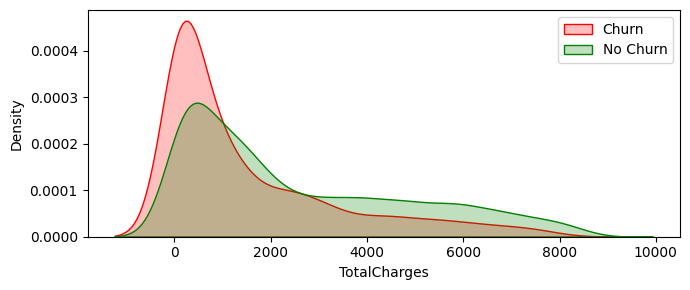

In [92]:
plt.figure(figsize=(7,3))
tc = sns.kdeplot(df.TotalCharges[df.Churn==1],fill=True,color='red')
tc = sns.kdeplot(df.TotalCharges[df.Churn==0],fill=True,color='green',ax=tc)
tc.legend(['Churn','No Churn'])
plt.tight_layout()
plt.show()

Surprisingly lower Total Charges lead to churn more despite of having positive coorrelation between Monthly and Total Charges.

TotalCharges is mathematically derived from MonthlyCharges and Tenure, its strong correlation with Tenure (0.83) indicates it primarily reflects customer lifecycle stage. Customers with lower TotalCharges are typically early-tenure users, who exhibit higher churn due to lower engagement and commitment, rather than lower spending

In [93]:
bins = [0, 3, 6, 12, 24, 48, 72]

labels = [
    '0-3 Months',
    '4-6 Months',
    '7-12 Months',
    '13-24 Months',
    '25-48 Months',
    '49+ Months'
]

df['tenure_bucket'] = pd.cut(df['tenure'], bins=bins, labels=labels, right=True)
df.tenure_bucket.value_counts()

tenure_bucket
49+ Months      2239
25-48 Months    1594
0-3 Months      1051
13-24 Months    1024
7-12 Months      705
4-6 Months       419
Name: count, dtype: int64

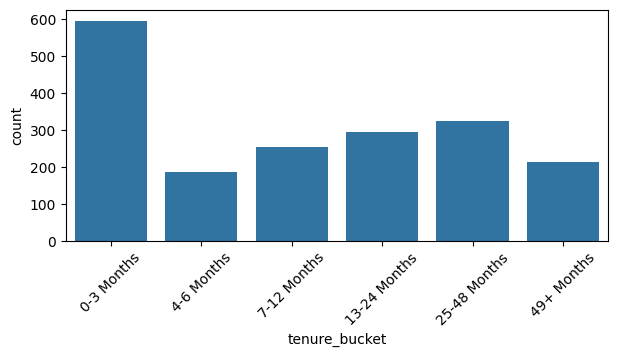

In [94]:
plt.figure(figsize=(7,3))
sns.countplot(data=df[df.Churn==1],x='tenure_bucket')
plt.xticks(rotation=45)
plt.show()

Customers with lower tenure (mostly <= 3 months) are high churner. Lower tenure with higher monthly charge leads to lower total_charge. As a result we saw lower total_charge leads to more churners

We do not need customer_id for analysis.

In [95]:
df = df.drop(['customerID'],axis=1)

In [96]:
df_dummy = pd.get_dummies(df,dtype=int)
df_dummy.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,...,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_bucket_0-3 Months,tenure_bucket_4-6 Months,tenure_bucket_7-12 Months,tenure_bucket_13-24 Months,tenure_bucket_25-48 Months,tenure_bucket_49+ Months
0,0,1,29.85,29.85,0,1,0,0,1,1,...,0,0,1,0,1,0,0,0,0,0
1,0,34,56.95,1889.50,0,0,1,1,0,1,...,0,0,0,1,0,0,0,0,1,0
2,0,2,53.85,108.15,1,0,1,1,0,1,...,0,0,0,1,1,0,0,0,0,0
3,0,45,42.30,1840.75,0,0,1,1,0,1,...,1,0,0,0,0,0,0,0,1,0
4,0,2,70.70,151.65,1,1,0,1,0,1,...,0,0,1,0,1,0,0,0,0,0


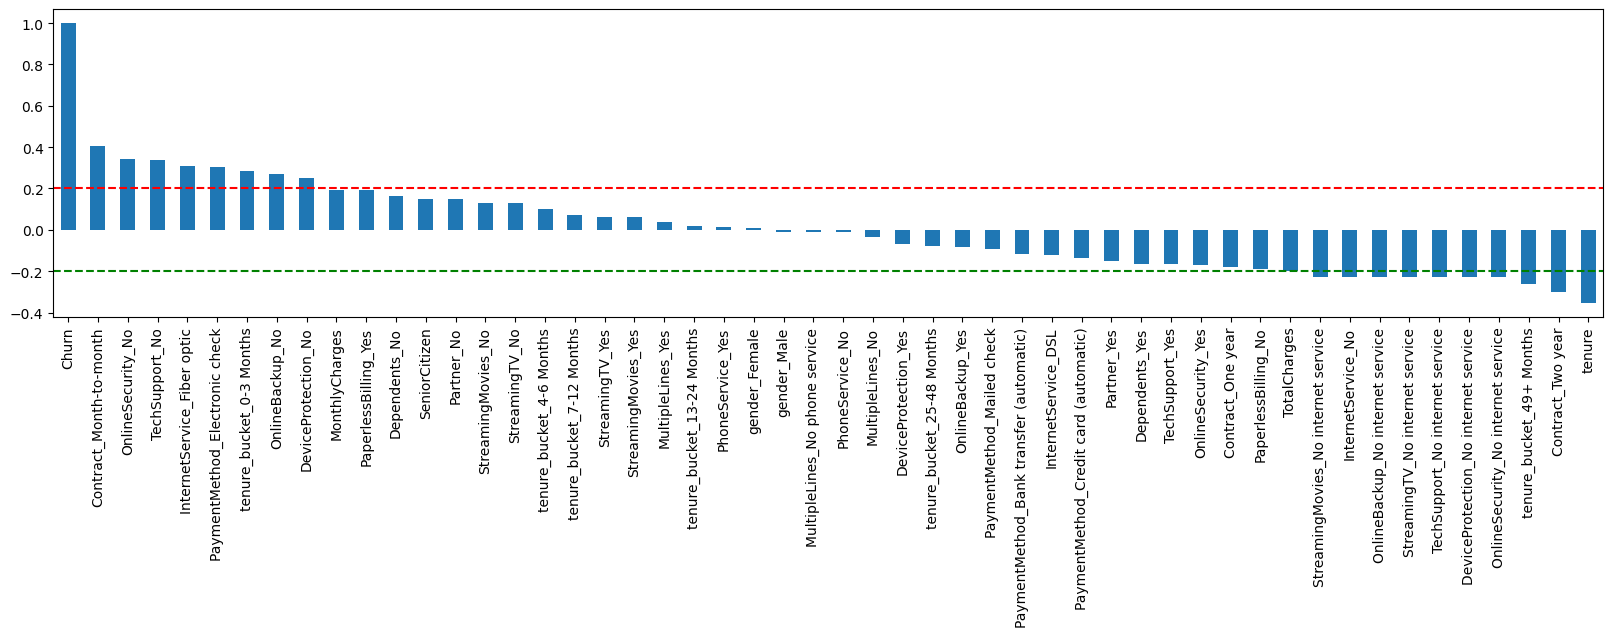

In [97]:
plt.figure(figsize=(20,4))
df_dummy.corr()['Churn'].sort_values(ascending=False).plot(kind='bar')
plt.axhline(y=0.2, linestyle='--',color='red')
plt.axhline(y=-0.2, linestyle='--',color='green')
plt.show()

In [98]:
df = df.drop(['tenure'],axis=1)
df_dummy = df_dummy.drop(['tenure'],axis=1)

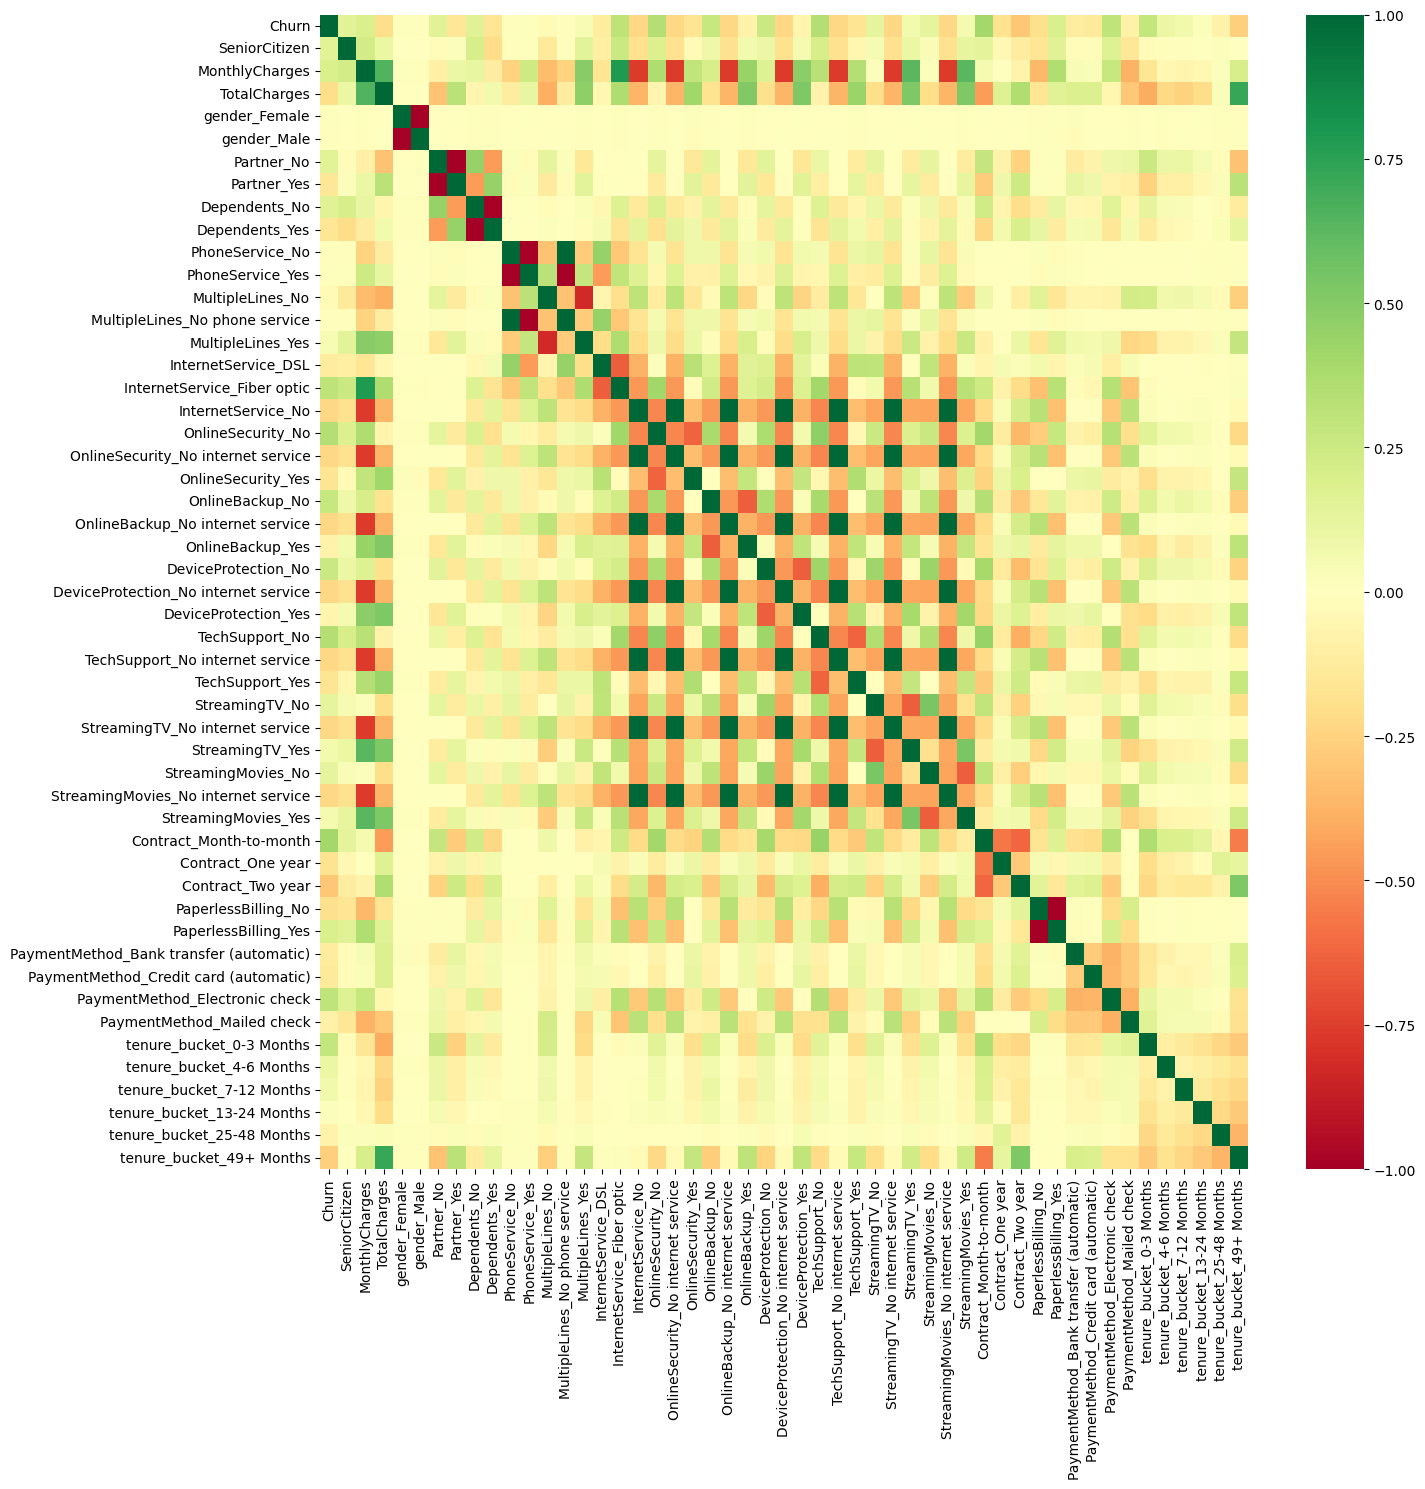

In [99]:
df_dummy_cols = ['Churn']+[col for col in df_dummy.columns if col != 'Churn']

plt.figure(figsize=(15,15))
sns.heatmap(df_dummy[df_dummy_cols].corr(),cmap='RdYlGn')
plt.tight_layout()
plt.show()

In [100]:
def f_bivariate_churn_analysis(df, col1, col2, target='Churn'):
    # Create grouped summary
    summary = (
        df.groupby([col1, col2])[target]
        .agg(['count', 'sum'])
        .reset_index()
    )
    
    # Rename columns
    summary.rename(columns={
        'count': 'total_customers',
        'sum': 'churned_customers'
    }, inplace=True)
    
    # Calculate churn rate
    summary['churn_rate'] = (summary['churned_customers'] / summary['total_customers'])*100
    
    # Sort by churn rate (descending)
    summary = summary.sort_values(by='churn_rate', ascending=False)
    
    return summary

In [101]:
f_bivariate_churn_analysis(df, 'gender', 'Partner')

,gender,Partner,total_customers,churned_customers,churn_rate
0,Female,No,1800,620,34.444444
2,Male,No,1839,580,31.538880
3,Male,Yes,1710,350,20.467836
1,Female,Yes,1683,319,18.954248


In [102]:
def f_plot_bivariate_churn(df, col1, col2, target='Churn'):
    # Aggregate data
    summary = (
        df.groupby([col1, col2])[target]
        .mean()
        .unstack()
    )

    # Plot
    #plt.figure(figsize=(7,2))
    summary.plot(kind='bar',figsize=(10,4))
    plt.title(f'Churn Rate by {col1} and {col2}')
    plt.ylabel('Churn Rate')
    plt.xlabel(col1)
    plt.xticks(rotation=0)
    plt.legend(title=col2)
    
    plt.show()

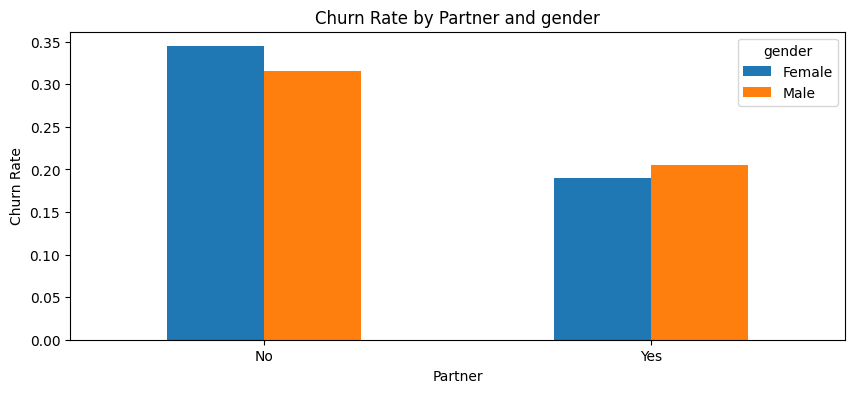

In [103]:
# Call function
f_plot_bivariate_churn(df, 'Partner', 'gender')

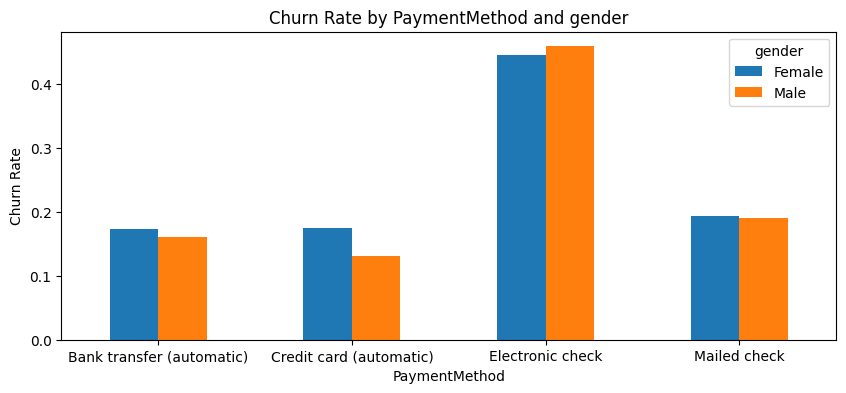

In [104]:
f_plot_bivariate_churn(df, 'PaymentMethod','gender')

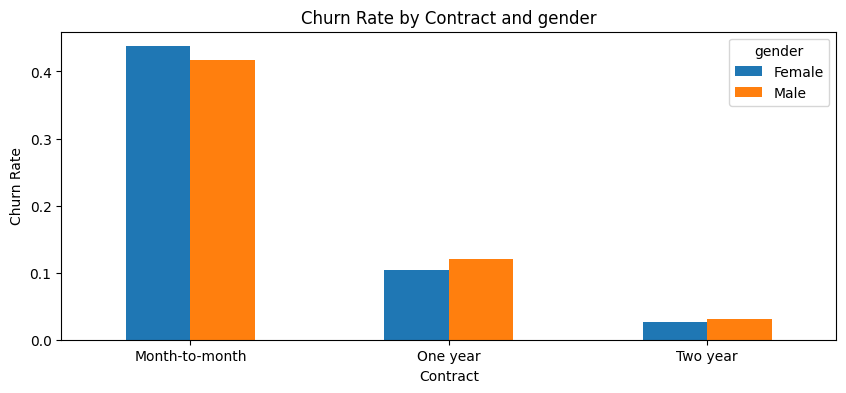

In [105]:
f_plot_bivariate_churn(df, 'Contract','gender')

In [106]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_bucket
0,Female,0,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,0-3 Months
1,Male,0,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0,25-48 Months
2,Male,0,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,0-3 Months
3,Male,0,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,25-48 Months
4,Female,0,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,0-3 Months


In [108]:
df.to_csv('customer_churn_cleaned.csv',index=False)